In [ ]:
!pip install kaggle



In [ ]:
ls

sample_data/


In [ ]:
!ls


sample_data


In [ ]:
!ls

sample_data


In [1]:
!ls


'archive (2).zip'   kagglecatsanddogs_5340.zip	 sample_data


In [2]:
!unzip "archive (2).zip"
!unzip kagglecatsanddogs_5340.zip


Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

In [3]:
!ls


'archive (2).zip'	   kagglecatsanddogs_5340.zip   sample_data
 CDLA-Permissive-2.0.pdf   PetImages
 chest_xray		  'readme[1].txt'


In [4]:
!ls chest_xray/train


NORMAL	PNEUMONIA


In [5]:
!ls PetImages


Cat  Dog


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import time


In [7]:
img_size = (224, 224)
batch_size = 32


In [8]:
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)


Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
base_model = VGG16(weights=None, include_top=False, input_shape=(224,224,3))

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
start = time.time()

history = model.fit(train_data, epochs=5, validation_data=test_data)

end = time.time()
print("Training Time:", end - start)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 169s 767ms/step - accuracy: 0.7189 - loss: 0.5963 - val_accuracy: 0.6250 - val_loss: 0.7793
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 83s 501ms/step - accuracy: 0.7344 - loss: 0.5877 - val_accuracy: 0.6250 - val_loss: 0.7169
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 82s 499ms/step - accuracy: 0.7340 - loss: 0.5828 - val_accuracy: 0.6250 - val_loss: 0.7082
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 82s 498ms/step - accuracy: 0.7534 - loss: 0.5597 - val_accuracy: 0.6250 - val_loss: 0.6770
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 82s 497ms/step - accuracy: 0.7333 - loss: 0.5818 - val_accuracy: 0.6250 - val_loss: 0.7046
Training Time: 497.6554710865021


In [11]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False   # freeze convolution layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history = model.fit(train_data, epochs=5, validation_data=test_data)
end = time.time()

print("Training Time:", end - start)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 65s 379ms/step - accuracy: 0.8665 - loss: 0.4608 - val_accuracy: 0.8301 - val_loss: 0.3911
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 58s 353ms/step - accuracy: 0.9538 - loss: 0.1192 - val_accuracy: 0.8333 - val_loss: 0.4287
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 59s 356ms/step - accuracy: 0.9642 - loss: 0.0967 - val_accuracy: 0.8494 - val_loss: 0.4073
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 59s 357ms/step - accuracy: 0.9727 - loss: 0.0862 - val_accuracy: 0.8221 - val_loss: 0.4546
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 59s 359ms/step - accuracy: 0.9821 - loss: 0.0611 - val_accuracy: 0.8654 - val_loss: 0.3891
Training Time: 299.67027592658997


In [12]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history = model.fit(train_data, epochs=5, validation_data=test_data)
end = time.time()

print("Training Time:", end - start)


Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 69s 395ms/step - accuracy: 0.8658 - loss: 0.3010 - val_accuracy: 0.7564 - val_loss: 0.9452
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 61s 371ms/step - accuracy: 0.9810 - loss: 0.0499 - val_accuracy: 0.8878 - val_loss: 0.4132
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - accuracy: 0.9915 - loss: 0.0252 - val_accuracy: 0.8189 - val_loss: 0.8094
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 61s 369ms/step - accuracy: 0.9944 - loss: 0.0129 - val_accuracy: 0.8654 - val_loss: 0.7398
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 61s 369ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.7692 - val_loss: 1.7470
Training Time: 313.69623613357544


In [13]:
train_dir = "PetImages"
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset="training"
)

test_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset="validation"
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [14]:
base_model = VGG16(weights=None, include_top=False, input_shape=(224,224,3))

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
model.fit(train_data, epochs=5, validation_data=test_data)
end = time.time()

print("Training Time:", end - start)


Epoch 1/5
 70/625 ━━━━━━━━━━━━━━━━━━━━ 4:13 457ms/step - accuracy: 0.5005 - loss: 0.6977

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


554/625 ━━━━━━━━━━━━━━━━━━━━ 32s 460ms/step - accuracy: 0.5018 - loss: 0.6941

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7b604831aed0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-p

In [15]:
import os
from PIL import Image

def remove_corrupted_images(folder):
    removed = 0
    for sub in ["Cat", "Dog"]:
        path = os.path.join(folder, sub)
        for file in os.listdir(path):
            fpath = os.path.join(path, file)
            try:
                img = Image.open(fpath)
                img.verify()
            except:
                os.remove(fpath)
                removed += 1
    print("Removed", removed, "corrupted images")

remove_corrupted_images("PetImages")


Removed 4 corrupted images


In [16]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    "PetImages",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset="training"
)

test_data = datagen.flow_from_directory(
    "PetImages",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset="validation"
)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [17]:
base_model = VGG16(weights=None, include_top=False, input_shape=(224,224,3))

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
model.fit(train_data, epochs=5, validation_data=test_data)
end = time.time()

print("Training Time:", end - start)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 505ms/step - accuracy: 0.4952 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 310s 495ms/step - accuracy: 0.4956 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 309s 495ms/step - accuracy: 0.5012 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 310s 495ms/step - accuracy: 0.5047 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 309s 495ms/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Training Time: 1560.778647184372


In [18]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
model.fit(train_data, epochs=5, validation_data=test_data)
end = time.time()

print("Training Time:", end - start)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 227ms/step - accuracy: 0.8501 - loss: 0.4909 - val_accuracy: 0.9282 - val_loss: 0.1751
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 225ms/step - accuracy: 0.9453 - loss: 0.1373 - val_accuracy: 0.9278 - val_loss: 0.1781
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.9650 - loss: 0.0903 - val_accuracy: 0.9208 - val_loss: 0.2122
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 217ms/step - accuracy: 0.9648 - loss: 0.0861 - val_accuracy: 0.9308 - val_loss: 0.2000
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 215ms/step - accuracy: 0.9773 - loss: 0.0600 - val_accuracy: 0.9190 - val_loss: 0.2300
Training Time: 693.7241675853729


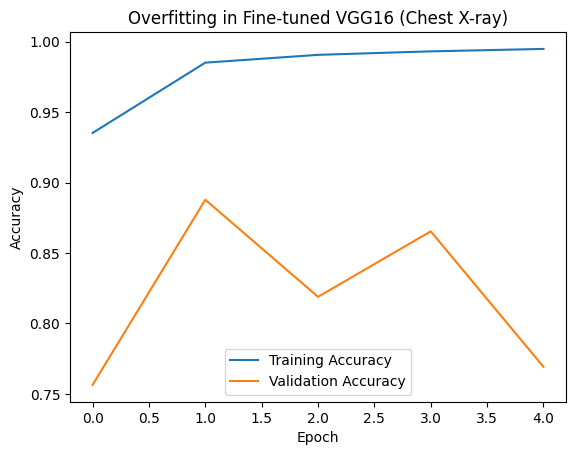

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting in Fine-tuned VGG16 (Chest X-ray)")
plt.legend()
plt.show()
